# EDA — Processed Bank Transactions

Exploratory analysis on the cleaned dataset produced by `etl-pipeline/transform.py`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 1. Load Processed Data

In [2]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

file = PROCESSED_DATA_DIR / "bank_transactions_cleaned.csv"

if not file.exists():
    raise FileNotFoundError(
        f"Processed file not found: {file}\n"
        "Run: python etl-pipeline/transform.py"
    )

df = pd.read_csv(file, parse_dates=["transaction_date"])

print(file.name)
print(f"Shape: {df.shape}")

bank_transactions_cleaned.csv
Shape: (6567, 17)


In [3]:
df.head()

,transaction_number,transaction_date,transaction_type,transaction_description,transaction_direction,debit_amount,credit_amount,amount,abs_amount,balance,category,location_city,location_country,year,month,year_month,day_of_week
0,6456,2015-01-09,FEE,ACCOUNT FEE,Debit,9.95,0.00,-9.95,9.95,9644.82,Bills,Swansea,UK,2015,1,2015-01,Friday
1,6457,2015-01-09,INT,INTEREST (NET),Credit,0.00,4.74,4.74,4.74,9654.77,Interest,Swansea,UK,2015,1,2015-01,Friday
2,6458,2015-01-09,DEB,EASYJET 000EPK,Debit,497.96,0.00,-497.96,497.96,9650.03,Travel,Unknown,Unknown,2015,1,2015-01,Friday
3,6459,2015-01-09,DEB,Amazon UK Marketpl,Debit,5.51,0.00,-5.51,5.51,10147.99,Amazon,Swansea,UK,2015,1,2015-01,Friday
4,6460,2015-01-09,DD,NATWEST BANK,Debit,748.13,0.00,-748.13,748.13,10153.50,Mortgage,Swansea,UK,2015,1,2015-01,Friday


In [4]:
df.tail()

,transaction_number,transaction_date,transaction_type,transaction_description,transaction_direction,debit_amount,credit_amount,amount,abs_amount,balance,category,location_city,location_country,year,month,year_month,day_of_week
6562,258,2022-12-05,BGC,NCC TRADE CRED NEW,Credit,0.00,150.0,150.00,150.00,1403.53,Supplementary Income,Nottingham,UK,2022,12,2022-12,Monday
6563,44,2022-12-07,FPO,CAPEWELL WINDOW CL,Debit,30.00,0.0,-30.00,30.00,1291.58,Home Improvement,Nottingham,UK,2022,12,2022-12,Wednesday
6564,45,2022-12-07,DEB,AMZNMktplace,Debit,12.99,0.0,-12.99,12.99,1321.58,Amazon,Nottingham,UK,2022,12,2022-12,Wednesday
6565,46,2022-12-07,DEB,AMZNMktplace,Debit,9.93,0.0,-9.93,9.93,1334.57,Amazon,Nottingham,UK,2022,12,2022-12,Wednesday
6566,47,2022-12-07,BP,SAVE THE CHANGE,Debit,0.28,0.0,-0.28,0.28,1344.50,Savings,Nottingham,UK,2022,12,2022-12,Wednesday


In [5]:
df.shape

(6567, 17)

In [6]:
df.columns.tolist()

['transaction_number',
 'transaction_date',
 'transaction_type',
 'transaction_description',
 'transaction_direction',
 'debit_amount',
 'credit_amount',
 'amount',
 'abs_amount',
 'balance',
 'category',
 'location_city',
 'location_country',
 'year',
 'month',
 'year_month',
 'day_of_week']

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6567 entries, 0 to 6566
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   transaction_number       6567 non-null   int64         
 1   transaction_date         6567 non-null   datetime64[us]
 2   transaction_type         6567 non-null   str           
 3   transaction_description  6567 non-null   str           
 4   transaction_direction    6567 non-null   str           
 5   debit_amount             6567 non-null   float64       
 6   credit_amount            6567 non-null   float64       
 7   amount                   6567 non-null   float64       
 8   abs_amount               6567 non-null   float64       
 9   balance                  6567 non-null   float64       
 10  category                 6567 non-null   str           
 11  location_city            6567 non-null   str           
 12  location_country         6567 non-null   str 

## 2. Summary Stats

### Numerical

In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
transaction_number,6567.0,3284.0,1.0,1642.5,3284.0,4925.5,6567.0,1895.873941
transaction_date,6567,2019-05-08 14:11:14.280493,2015-01-09 00:00:00,2017-06-30 00:00:00,2019-07-19 00:00:00,2021-03-31 00:00:00,2022-12-07 00:00:00,NaN
debit_amount,6567.0,77.840554,0.0,1.555,10.0,31.99,84000.0,1069.132404
credit_amount,6567.0,76.626053,0.0,0.0,0.0,0.0,83840.54,1121.76608
amount,6567.0,-1.214501,-84000.0,-31.99,-10.0,-1.555,83840.54,1553.490998
abs_amount,6567.0,154.466607,0.01,3.0,12.9,40.0,84000.0,1545.791767
balance,6567.0,8409.749756,65.61,1872.98,7551.85,14381.42,94066.01,6839.368572
year,6567.0,2018.890818,2015.0,2017.0,2019.0,2021.0,2022.0,2.147214
month,6567.0,6.051165,1.0,3.0,6.0,9.0,12.0,3.548773


### Categoricals

In [10]:
df.describe(include=["object", "string"]).T

,count,unique,top,freq
transaction_type,6567,14,DEB,3268
transaction_description,6567,908,SAVE THE CHANGE,1165
transaction_direction,6567,2,Debit,6122
category,6567,30,Savings,1249
location_city,6567,55,Swansea,3162
location_country,6567,16,UK,5826
year_month,6567,96,2021-01,157
day_of_week,6567,7,Monday,1710


## 3. Missing Values

After transform, nulls should be fully resolved.

In [11]:
missing = (
    df.isnull()
      .sum()
      .to_frame("Missing")
)

missing["Percent"] = (
    missing["Missing"] / len(df) * 100
)

missing.sort_values("Missing", ascending=False)

,Missing,Percent
transaction_number,0,0.0
transaction_date,0,0.0
transaction_type,0,0.0
transaction_description,0,0.0
transaction_direction,0,0.0
debit_amount,0,0.0
credit_amount,0,0.0
amount,0,0.0
abs_amount,0,0.0
balance,0,0.0


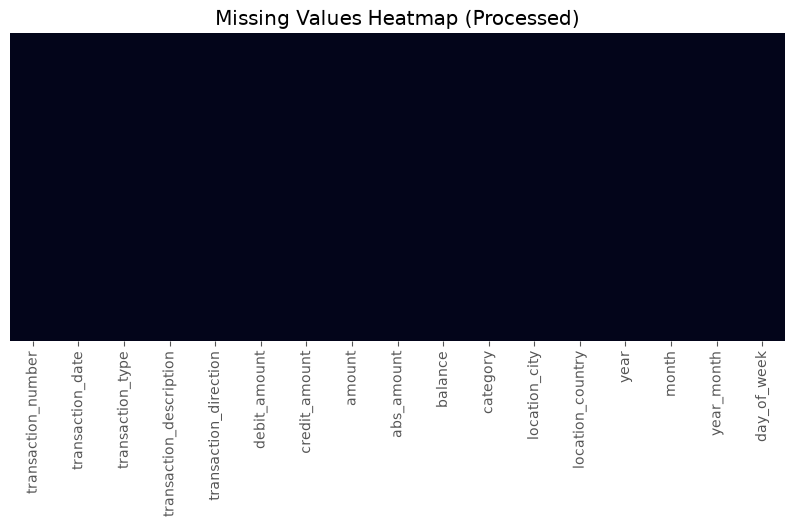

In [12]:
plt.figure(figsize=(10, 4))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap (Processed)")
plt.show()

## 4. Duplicate Records

In [13]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


## 5. Case Inconsistency Check

After transform, categorical labels should be case-standardized (e.g. `Swansea` vs `swansea` should collapse to one value). This check validates that normalization worked.

In [14]:
case_check_cols = [
    "transaction_type",
    "category",
    "location_city",
    "location_country",
]

case_collisions = []

for col in case_check_cols:
    values = df[col].dropna().astype(str).str.strip()
    groups = {}

    for value in values.unique():
        groups.setdefault(value.casefold(), set()).add(value)

    for key, variants in groups.items():
        if len(variants) > 1:
            case_collisions.append({
                "Column": col,
                "Canonical": key,
                "Variants": sorted(variants),
                "Variant Count": len(variants),
                "Row Count": int(values.str.casefold().eq(key).sum()),
            })

if case_collisions:
    case_df = pd.DataFrame(case_collisions)
    display(case_df)
else:
    print("No case-only duplicate labels found.")

No case-only duplicate labels found.


## 6. Data Types

In [15]:
df.dtypes

transaction_number                  int64
transaction_date           datetime64[us]
transaction_type                      str
transaction_description               str
transaction_direction                 str
debit_amount                      float64
credit_amount                     float64
amount                            float64
abs_amount                        float64
balance                           float64
category                              str
location_city                         str
location_country                      str
year                                int64
month                               int64
year_month                            str
day_of_week                           str
dtype: object

## 7. Unique Values

In [16]:
unique = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Data Type": df.dtypes
})

unique

,Unique Values,Data Type
transaction_number,6567,int64
transaction_date,1660,datetime64[us]
transaction_type,14,str
transaction_description,908,str
transaction_direction,2,str
debit_amount,2036,float64
credit_amount,268,float64
amount,2302,float64
abs_amount,2194,float64
balance,6507,float64


## 8. Numerical Features

In [17]:
numeric_cols = [
    "debit_amount",
    "credit_amount",
    "amount",
    "abs_amount",
    "balance",
]

numeric_cols

['debit_amount', 'credit_amount', 'amount', 'abs_amount', 'balance']

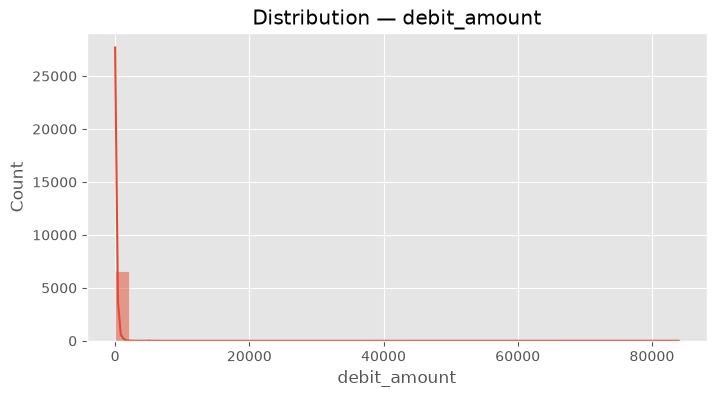

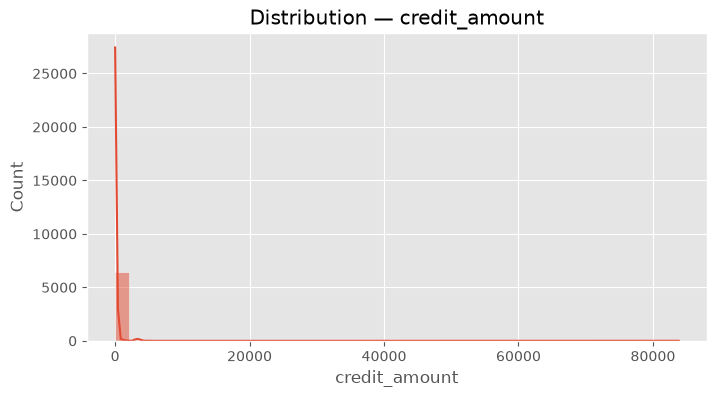

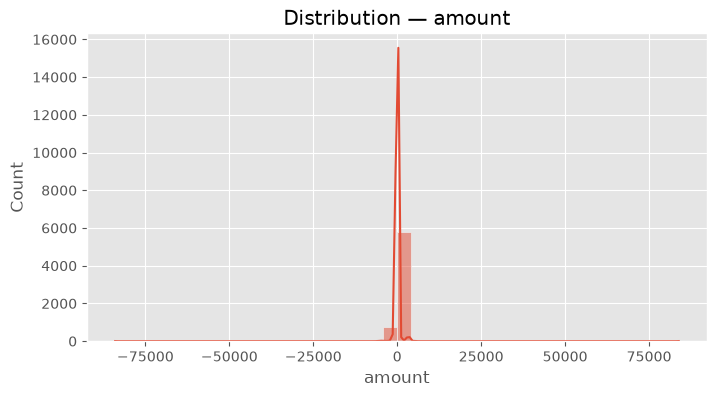

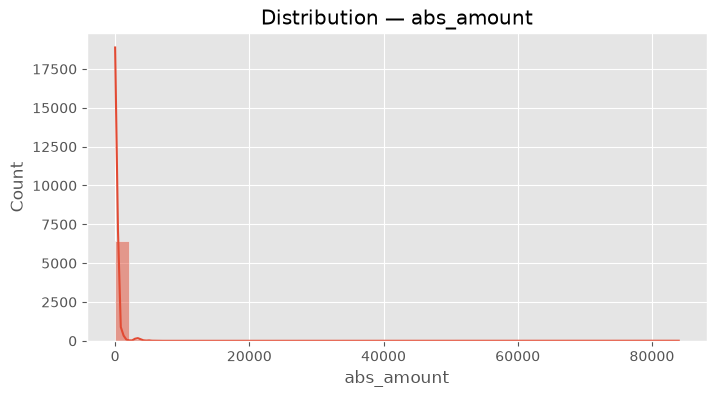

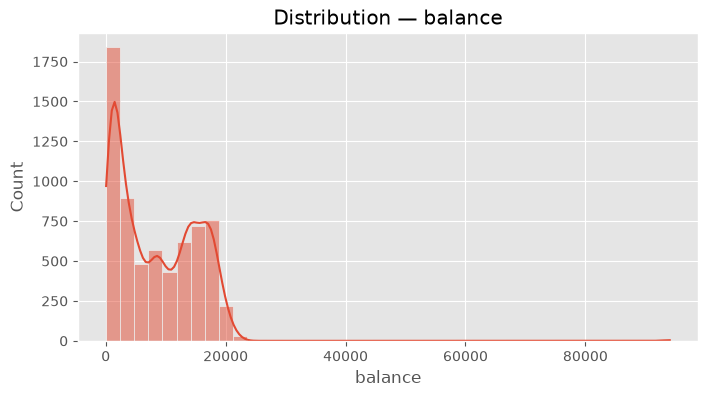

In [18]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=40, kde=True)
    plt.title(f"Distribution — {col}")
    plt.show()

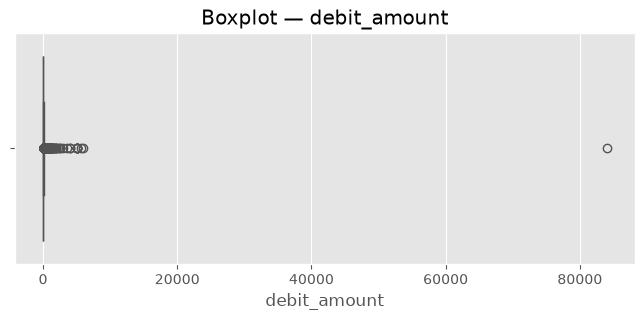

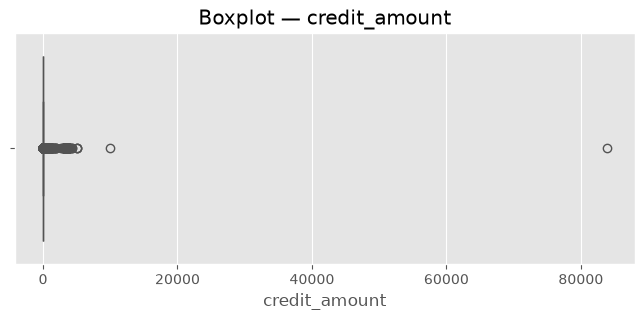

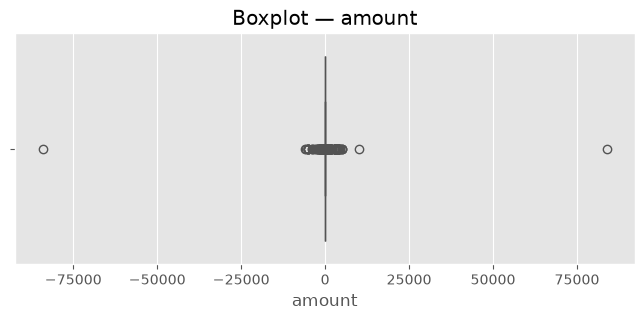

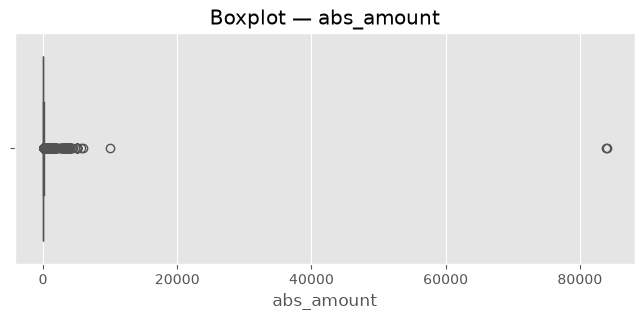

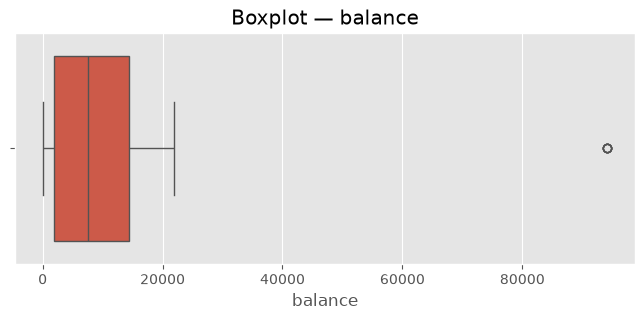

In [19]:
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot — {col}")
    plt.show()

## 9. Categorical Features

In [20]:
categorical_cols = [
    "transaction_type",
    "transaction_direction",
    "category",
    "location_city",
    "location_country",
    "day_of_week",
]

categorical_cols

['transaction_type',
 'transaction_direction',
 'category',
 'location_city',
 'location_country',
 'day_of_week']

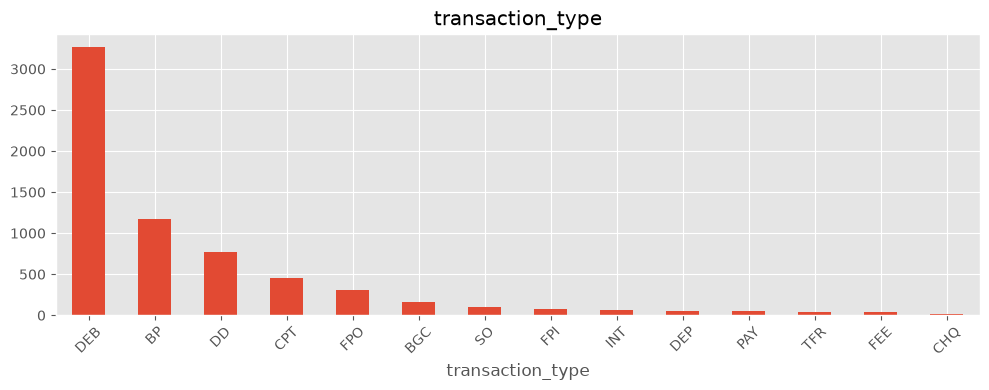

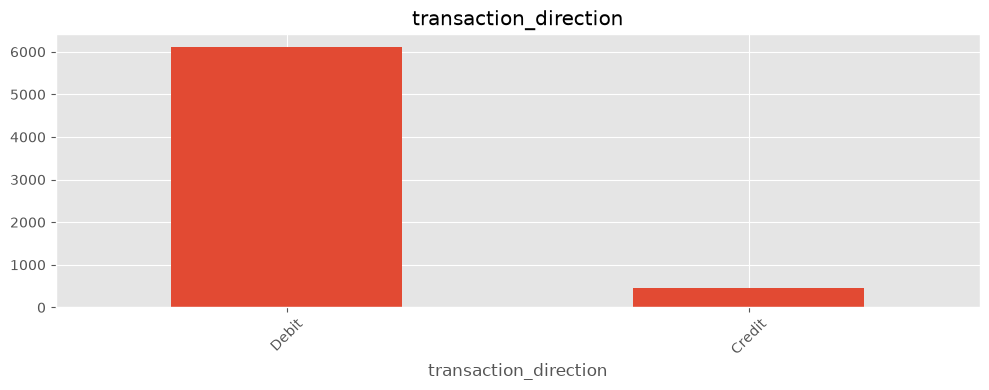

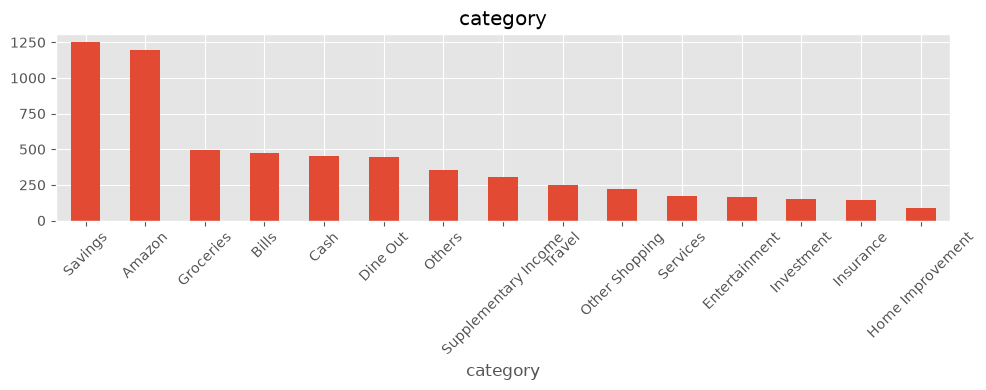

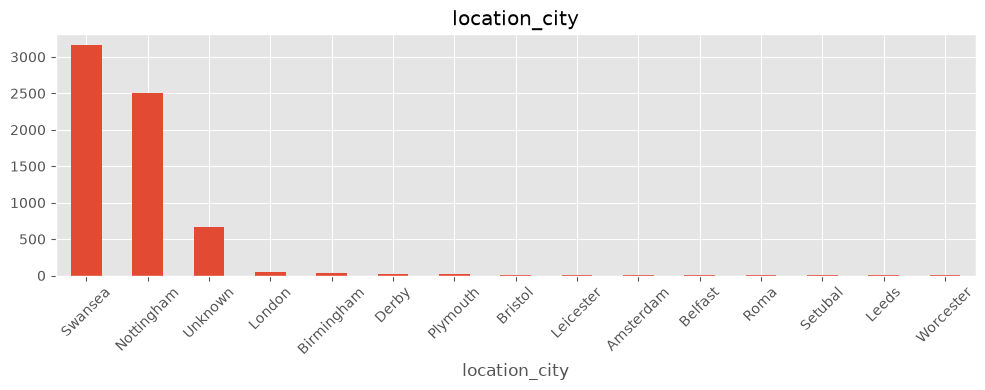

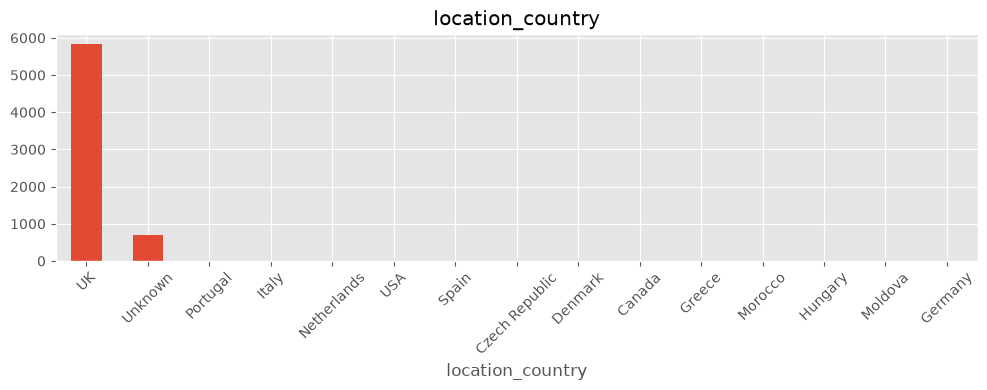

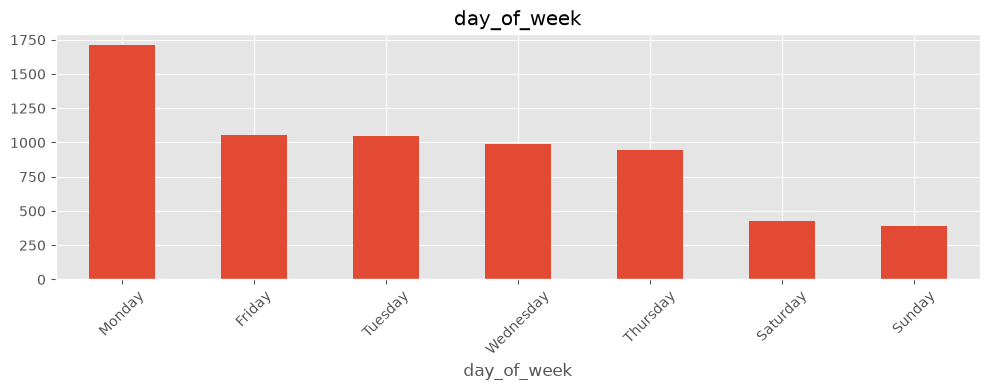

In [22]:
for col in categorical_cols:
    plt.figure(figsize=(10, 4))

    (
        df[col]
        .value_counts()
        .head(15)
        .plot(kind="bar")
    )

    plt.title(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 10. Correlation Analysis

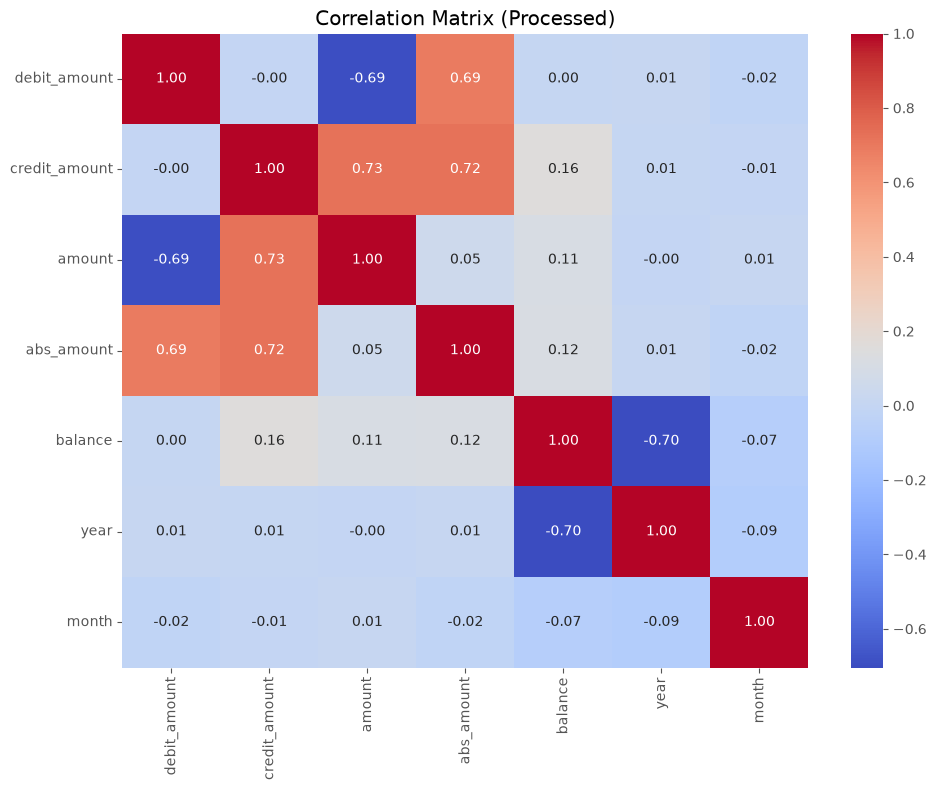

In [ ]:
corr = df[numeric_cols + ["year", "month"]].corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix (Processed)")
plt.tight_layout()
plt.show()

## 11. Outlier Detection

In [24]:
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

debit_amount: 794 outliers
credit_amount: 445 outliers
amount: 1077 outliers
abs_amount: 960 outliers
balance: 5 outliers


## 12. Time-Series Trends

Uses derived date features from the transform step.

In [25]:
print(f"Date range: {df['transaction_date'].min().date()} -> {df['transaction_date'].max().date()}")
print(f"Years covered: {sorted(df['year'].unique())}")

Date range: 2015-01-09 -> 2022-12-07
Years covered: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


In [26]:
monthly = (
    df.groupby("year_month", as_index=False)
      .agg(
          transactions=("transaction_number", "count"),
          total_debit=("debit_amount", "sum"),
          total_credit=("credit_amount", "sum"),
          avg_balance=("balance", "mean"),
      )
)

monthly.head()

,year_month,transactions,total_debit,total_credit,avg_balance
0,2015-01,36,4417.28,14.38,10599.909167
1,2015-02,26,2402.46,5.23,9863.213846
2,2015-03,29,3283.41,590.69,9692.874828
3,2015-04,13,288.13,0.00,9041.272308
4,2015-05,18,155.74,0.00,9257.251111


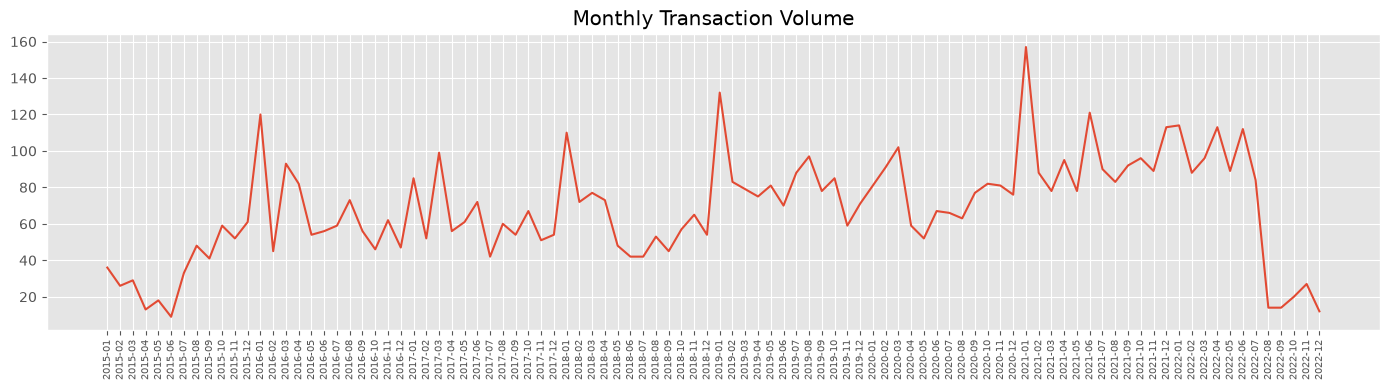

In [27]:
plt.figure(figsize=(14, 4))
plt.plot(monthly["year_month"], monthly["transactions"])
plt.title("Monthly Transaction Volume")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

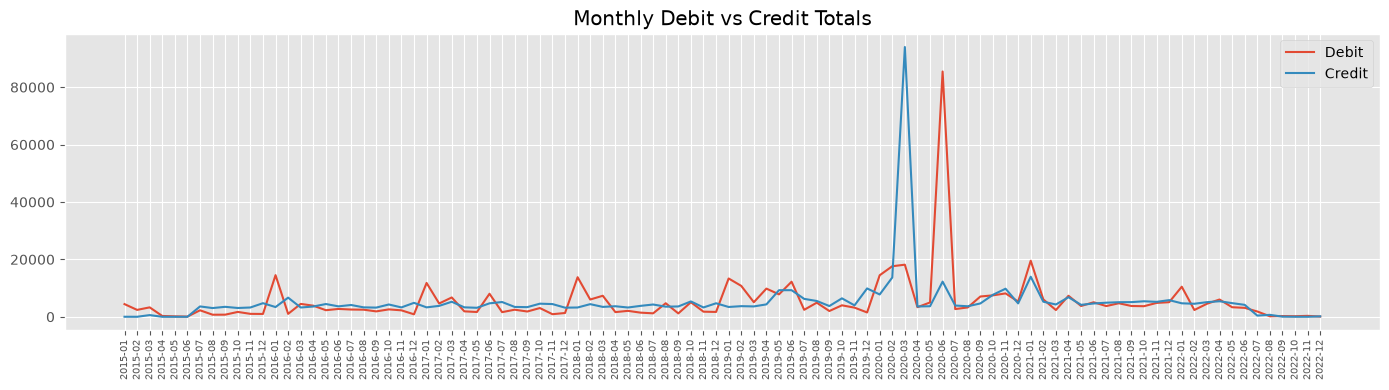

In [28]:
plt.figure(figsize=(14, 4))
plt.plot(monthly["year_month"], monthly["total_debit"], label="Debit")
plt.plot(monthly["year_month"], monthly["total_credit"], label="Credit")
plt.title("Monthly Debit vs Credit Totals")
plt.xticks(rotation=90, fontsize=7)
plt.legend()
plt.tight_layout()
plt.show()

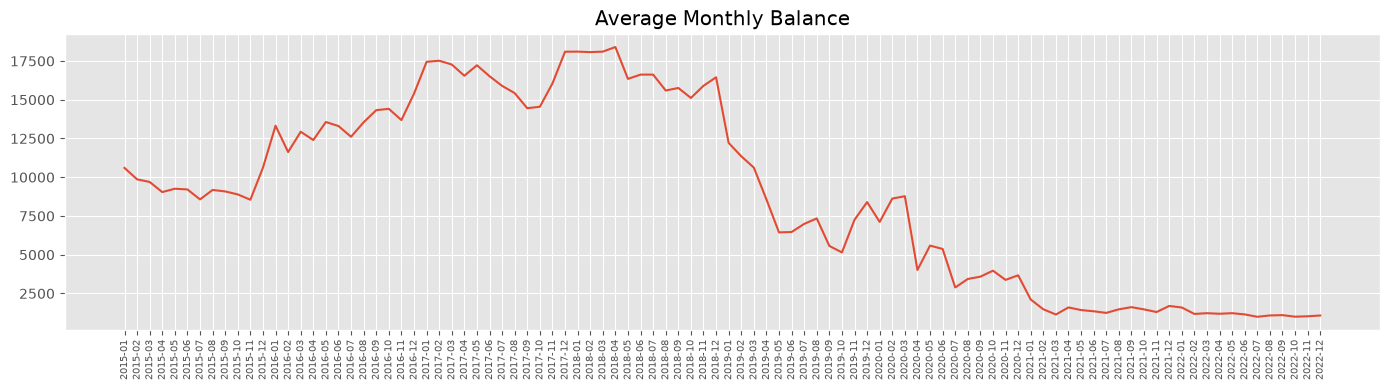

In [30]:
plt.figure(figsize=(14, 4))
plt.plot(monthly["year_month"], monthly["avg_balance"])
plt.title("Average Monthly Balance")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

## 13. Spending & Income Patterns

In [31]:
direction_summary = (
    df.groupby("transaction_direction")
      .agg(
          count=("transaction_number", "count"),
          total_abs_amount=("abs_amount", "sum"),
          avg_abs_amount=("abs_amount", "mean"),
      )
)

direction_summary

,count,total_abs_amount,avg_abs_amount
transaction_direction,,,
Credit,445,503203.29,1130.79391
Debit,6122,511178.92,83.49868


In [32]:
category_spend = (
    df[df["transaction_direction"] == "Debit"]
      .groupby("category", as_index=False)
      .agg(
          transactions=("transaction_number", "count"),
          total_spent=("debit_amount", "sum"),
          avg_spent=("debit_amount", "mean"),
      )
      .sort_values("total_spent", ascending=False)
)

category_spend.head(15)

,category,transactions,total_spent,avg_spent
14,Investment,151,128614.88,851.754172
0,Account Transfer,1,84000.00,84000.000000
15,Mortgage,58,56392.70,972.287931
2,Bills,474,43269.55,91.285970
3,Cash,453,27661.98,61.063974
21,Savings,1249,26682.96,21.363459
22,Services,171,23916.31,139.861462
1,Amazon,1183,21271.45,17.980938
25,Travel,246,19164.29,77.903618
11,Home Improvement,89,18369.52,206.399101


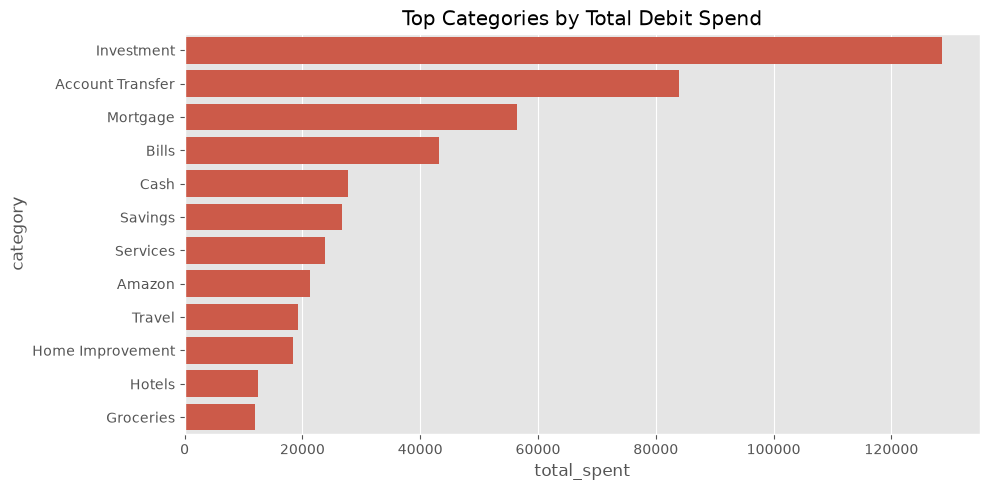

In [33]:
plt.figure(figsize=(10, 5))

top_categories = category_spend.head(12)

sns.barplot(
    data=top_categories,
    x="total_spent",
    y="category",
)

plt.title("Top Categories by Total Debit Spend")
plt.tight_layout()
plt.show()

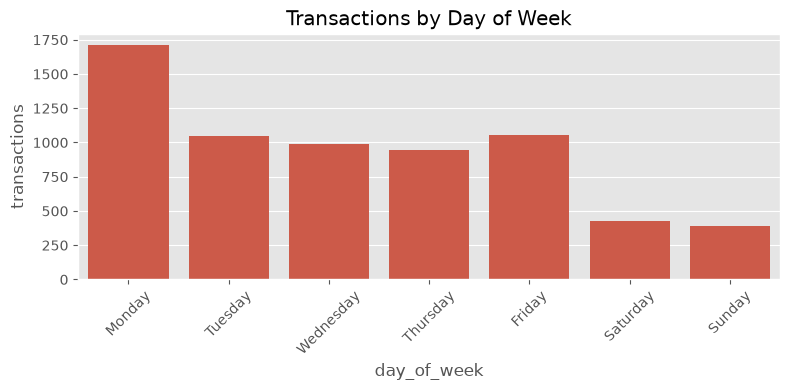

In [34]:
dow_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday",
]

dow = (
    df.groupby("day_of_week", as_index=False)
      .agg(
          transactions=("transaction_number", "count"),
          total_abs_amount=("abs_amount", "sum"),
      )
)

dow["day_of_week"] = pd.Categorical(dow["day_of_week"], categories=dow_order, ordered=True)
dow = dow.sort_values("day_of_week")

plt.figure(figsize=(8, 4))
sns.barplot(data=dow, x="day_of_week", y="transactions")
plt.title("Transactions by Day of Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 14. Location Insights

In [37]:
city_summary = (
    df.groupby("location_city", as_index=False)
      .agg(
          transactions=("transaction_number", "count"),
          total_abs_amount=("abs_amount", "sum"),
      )
      .sort_values("transactions", ascending=False)
)

city_summary.head(15)

,location_city,transactions,total_abs_amount
50,Swansea,3162,399037.19
34,Nottingham,2502,563874.48
51,Unknown,672,35560.73
25,London,50,640.81
7,Birmingham,30,921.43
16,Derby,16,223.74
38,Plymouth,15,798.85
9,Bristol,13,640.33
23,Leicester,9,812.64
5,Belfast,7,172.18


In [38]:
country_summary = (
    df.groupby("location_country", as_index=False)
      .agg(
          transactions=("transaction_number", "count"),
          total_abs_amount=("abs_amount", "sum"),
      )
      .sort_values("transactions", ascending=False)
)

country_summary

,location_country,transactions,total_abs_amount
13,UK,5826,968786.65
15,Unknown,686,36220.55
7,Italy,8,887.28
11,Portugal,8,604.80
10,Netherlands,7,130.41
12,Spain,6,1307.94
14,USA,6,2220.52
0,Canada,4,1510.77
1,Czech Republic,4,462.26
2,Denmark,4,77.71


## Findings

- Processed data has no missing values and no duplicate rows.
- Case-only label collisions (e.g. `Swansea` vs `swansea`) are resolved after transform.
- Debit/credit sides are unified via `transaction_direction`, `amount`, and `abs_amount`.
- Derived date fields support monthly volume, spend, and balance trend analysis.
- Category and location fields are cleaned and ready for BI / load into the database.
- UK is the country with the highest no. of transactions while in terms of city, Swansea has the highest one. 
- There are more debit than credit transactions.
- Monday is the day of week with the highest volume of transactions.